Environment Setup

In [4]:
pip install scikit-learn xgboost lightgbm catboost joblib


Real-Estate Multi-Model Training

In [6]:
# 0. --- Imports & config ----------------------------------------------------
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import warnings
warnings.filterwarnings("ignore")

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# ------------- paths & general settings -------------------------------------
DATA_PATH = r"C:\Users\91786\Desktop\Real_Estate_Price\data_clean\mumbai_full_enriched.csv"
OUT_MODELS_DIR = r"C:\Users\91786\Desktop\Real_Estate_Price\models"
os.makedirs(OUT_MODELS_DIR, exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE = 0.20


In [7]:
# 1. --- Load dataset --------------------------------------------------------
df = pd.read_csv(DATA_PATH)
print("Loaded:", df.shape)
df.head()


Loaded: (55176, 14)


,city,location,region,bhk,total_sqft,property_type,availability,price,price_per_sqft,latitude,longitude,ndvi,ndbi,nightlight
0,Mumbai,Lak And Hanware The Residency Tower,andheri west,3.0,685.0,Apartment,Ready to move,250.00,0.364964,19.117249,72.833968,0.816180,-0.361702,39.349167
1,Mumbai,Radheya Sai Enclave Building No 2,naigaon east,2.0,640.0,Apartment,Under Construction,52.51,0.082047,19.013803,72.846322,0.333117,-0.022620,46.023335
2,Mumbai,Romell Serene,borivali west,2.0,610.0,Apartment,Under Construction,173.00,0.283607,19.229813,72.847138,0.736824,-0.242790,39.416668
3,Mumbai,Soundlines Codename Urban Rainforest,panvel,2.0,876.0,Apartment,Under Construction,59.98,0.068470,19.046336,72.908887,0.280667,-0.029027,44.340832
4,Mumbai,Origin Oriana,mira road east,2.0,659.0,Apartment,Under Construction,94.11,0.142807,19.294887,72.867843,0.127551,0.064974,45.810833


In [10]:
# 2. --- Quick cleaning / target check --------------------------------------
# Ensure price exists and is numeric; if not, convert or clean accordingly
if 'price' not in df.columns:
    # If your dataset uses 'price_in_lakh' or 'price_value' replace accordingly
    raise KeyError("Target column 'price' not found. Update the code to use correct target column.")

# Drop exact-duplicate rows (you reported duplicates earlier)
df = df.drop_duplicates()
print("After dropping duplicates:", df.shape)

# Optional: drop any columns you don't want as features
# e.g., drop 'city' and exact 'location' text (keeps region) to avoid huge OneHot
if 'city' in df.columns:
    df = df.drop(columns=['city'])
if 'location' in df.columns:
    # location text is high-cardinality; remove for now (we keep 'region')
    df = df.drop(columns=['location'])
if "price_per_sqft" in df.columns:
    df = df.drop(columns=["price_per_sqft"])
    print("Dropped price_per_sqft (leakage column).")



After dropping duplicates: (50808, 11)


In [11]:
# 3. --- Feature selection ---------------------------------------------------
# list current columns for clarity
print("Columns:", df.columns.tolist())

# Define X, y
target_col = 'price'
X = df.drop(columns=[target_col])
y = df[target_col].astype(float)  # ensure numeric

# Identify categorical and numeric columns (simple heuristic)
cat_cols = [c for c in X.columns if X[c].dtype == 'object' or c in ['region','property_type','availability']]
num_cols = [c for c in X.columns if c not in cat_cols]

print("Numeric cols:", num_cols)
print("Categorical cols:", cat_cols)


Columns: ['region', 'bhk', 'total_sqft', 'property_type', 'availability', 'price', 'latitude', 'longitude', 'ndvi', 'ndbi', 'nightlight']
Numeric cols: ['bhk', 'total_sqft', 'latitude', 'longitude', 'ndvi', 'ndbi', 'nightlight']
Categorical cols: ['region', 'property_type', 'availability']


In [12]:
# 4. --- Train / Test split --------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE,
                                                    random_state=RANDOM_STATE)
print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (40646, 10) Test: (10162, 10)


In [13]:
# 5. --- Preprocessor pipeline -----------------------------------------------
# numeric: StandardScaler; categorical: OneHot (ignore unknowns)
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ],
    remainder='drop',
    verbose_feature_names_out=False
)


In [14]:
# 6. --- Define models to train ----------------------------------------------
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "Lasso": Lasso(alpha=0.01, random_state=RANDOM_STATE),
    "DecisionTree": DecisionTreeRegressor(max_depth=15, random_state=RANDOM_STATE),
    "RandomForest": RandomForestRegressor(n_estimators=150, max_depth=20, random_state=RANDOM_STATE, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=150, learning_rate=0.1, random_state=RANDOM_STATE),
    "XGBoost": XGBRegressor(n_estimators=200, learning_rate=0.08, max_depth=8, random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
    "LightGBM": LGBMRegressor(n_estimators=200, learning_rate=0.08, random_state=RANDOM_STATE, n_jobs=-1),
    "CatBoost": CatBoostRegressor(iterations=200, learning_rate=0.08, depth=8, verbose=0, random_state=RANDOM_STATE),
    # Online / incremental model (good for continuous learning)
    "SGDRegressor": SGDRegressor(max_iter=1000, tol=1e-3, random_state=RANDOM_STATE)
}


In [15]:
# 7. --- Train & evaluate each model -----------------------------------------
results = []

for name, model in models.items():
    print("\n=========================================================")
    print(f"🔵 Training Model: {name}")
    print("=========================================================")

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # Train
    pipeline.fit(X_train, y_train)

    # Predict
    y_pred = pipeline.predict(X_test)

    # Metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    # Print results immediately
    print(f"📌 Results for {name}:")
    print(f"   ➤ MAE : {mae:.3f}")
    print(f"   ➤ RMSE: {rmse:.3f}")
    print(f"   ➤ R²  : {r2:.4f}")

    # Save results
    results.append({
        "model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    # Save model pipeline
    out_path = os.path.join(OUT_MODELS_DIR, f"{name}_pipeline.joblib")
    joblib.dump(pipeline, out_path)
    print(f"💾 Saved trained pipeline: {out_path}")

# After all models finish, show summary
print("\n==================== FINAL MODEL RANKING =====================")
results_df = pd.DataFrame(results).sort_values(by="R2", ascending=False)
display(results_df)

# Save ranking to file
results_df.to_csv(os.path.join(OUT_MODELS_DIR, "model_comparison_summary.csv"), index=False)
print("📁 Summary saved successfully.")



🔵 Training Model: LinearRegression
📌 Results for LinearRegression:
   ➤ MAE : 57.797
   ➤ RMSE: 114.377
   ➤ R²  : 0.7693
💾 Saved trained pipeline: C:\Users\91786\Desktop\Real_Estate_Price\models\LinearRegression_pipeline.joblib

🔵 Training Model: Ridge
📌 Results for Ridge:
   ➤ MAE : 57.863
   ➤ RMSE: 114.391
   ➤ R²  : 0.7692
💾 Saved trained pipeline: C:\Users\91786\Desktop\Real_Estate_Price\models\Ridge_pipeline.joblib

🔵 Training Model: Lasso
📌 Results for Lasso:
   ➤ MAE : 57.786
   ➤ RMSE: 114.779
   ➤ R²  : 0.7677
💾 Saved trained pipeline: C:\Users\91786\Desktop\Real_Estate_Price\models\Lasso_pipeline.joblib

🔵 Training Model: DecisionTree
📌 Results for DecisionTree:
   ➤ MAE : 36.955
   ➤ RMSE: 106.079
   ➤ R²  : 0.8016
💾 Saved trained pipeline: C:\Users\91786\Desktop\Real_Estate_Price\models\DecisionTree_pipeline.joblib

🔵 Training Model: RandomForest
📌 Results for RandomForest:
   ➤ MAE : 33.147
   ➤ RMSE: 90.438
   ➤ R²  : 0.8558
💾 Saved trained pipeline: C:\Users\91786\Des

,model,MAE,RMSE,R2
7,LightGBM,34.219106,87.376360,0.865362
8,CatBoost,35.715223,87.776357,0.864126
6,XGBoost,33.349915,88.879585,0.860689
5,GradientBoosting,40.819826,90.371976,0.855972
4,RandomForest,33.146988,90.437839,0.855762
3,DecisionTree,36.955332,106.078545,0.801557
0,LinearRegression,57.797096,114.376726,0.769296
1,Ridge,57.862912,114.391063,0.769238
2,Lasso,57.786010,114.779218,0.767669
9,SGDRegressor,57.886664,115.195729,0.765980


📁 Summary saved successfully.


Code to Plot Model Performance

In [17]:
pip install seaborn


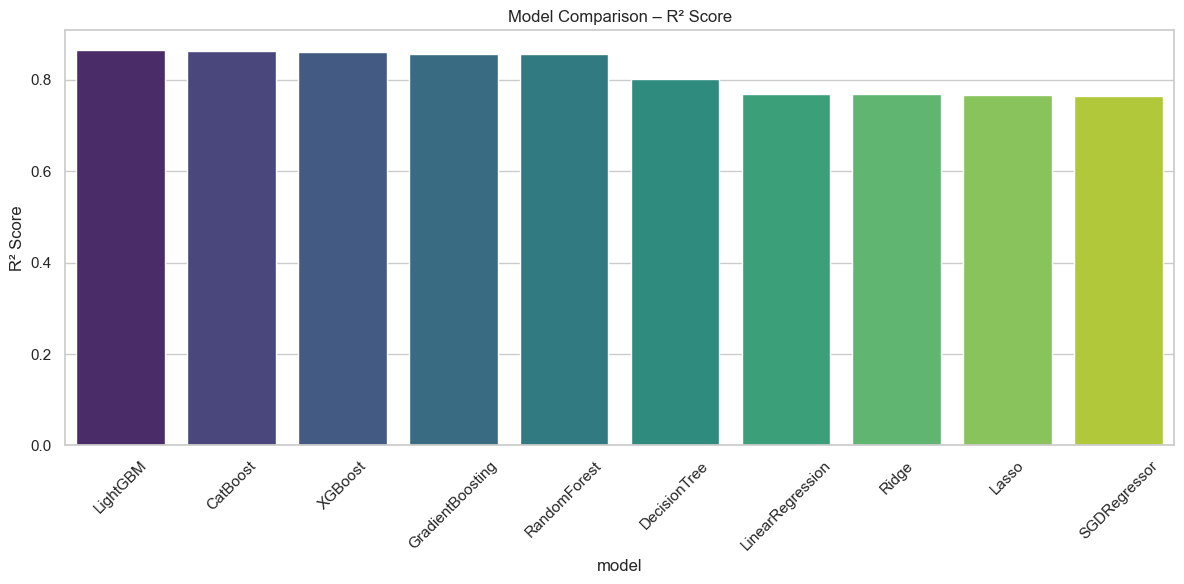

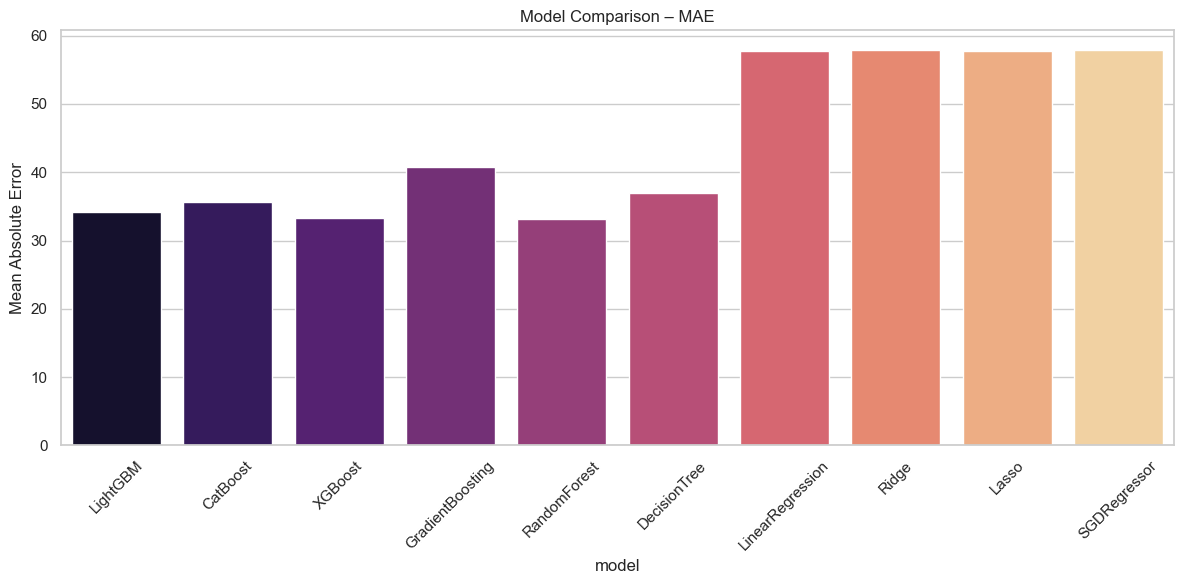

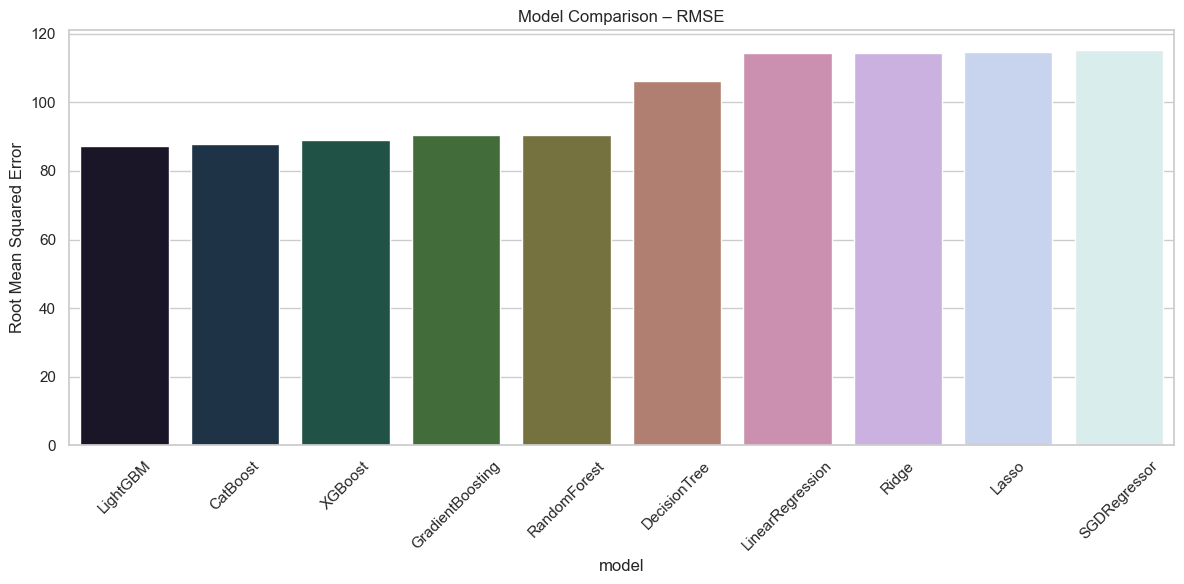

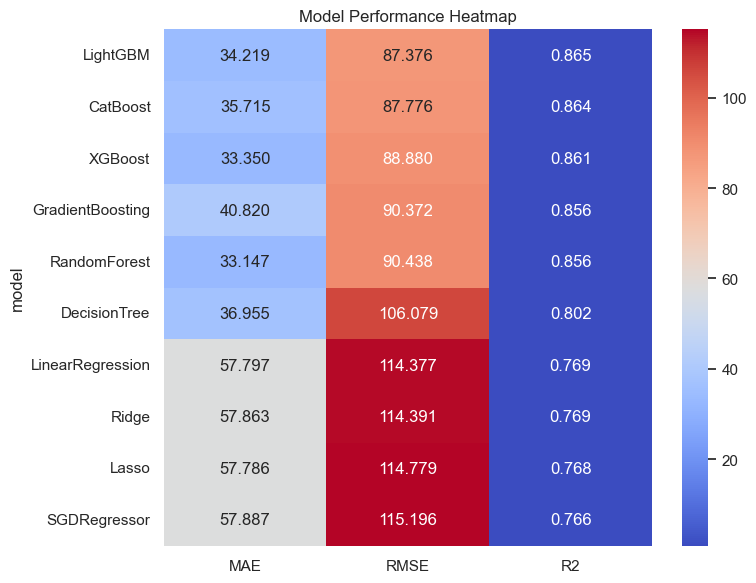

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Load the comparison CSV (or use results_df directly if in memory)
comparison_path = r"C:\Users\91786\Desktop\Real_Estate_Price\models\model_comparison_summary.csv"
results_df = pd.read_csv(comparison_path)

# ---------------- PLOT 1: R² Score Ranking ----------------
plt.figure(figsize=(12,6))
sns.barplot(data=results_df, x="model", y="R2", palette="viridis")
plt.xticks(rotation=45)
plt.title("Model Comparison – R² Score")
plt.ylabel("R² Score")
plt.tight_layout()
plt.show()

# ---------------- PLOT 2: MAE Comparison ----------------
plt.figure(figsize=(12,6))
sns.barplot(data=results_df, x="model", y="MAE", palette="magma")
plt.xticks(rotation=45)
plt.title("Model Comparison – MAE")
plt.ylabel("Mean Absolute Error")
plt.tight_layout()
plt.show()

# ---------------- PLOT 3: RMSE Comparison ----------------
plt.figure(figsize=(12,6))
sns.barplot(data=results_df, x="model", y="RMSE", palette="cubehelix")
plt.xticks(rotation=45)
plt.title("Model Comparison – RMSE")
plt.ylabel("Root Mean Squared Error")
plt.tight_layout()
plt.show()

# ---------------- PLOT 4: Combined Metric Heatmap ----------------
plt.figure(figsize=(8,6))
sns.heatmap(results_df.set_index("model"), annot=True, cmap="coolwarm", fmt=".3f")
plt.title("Model Performance Heatmap")
plt.tight_layout()
plt.show()


Performance Summary Table

In [18]:
from IPython.display import display

display(results_df.style.highlight_max(color='lightgreen', axis=0)
                             .highlight_min(color='salmon', axis=0))


,model,MAE,RMSE,R2
0,LightGBM,34.219106,87.376360,0.865362
1,CatBoost,35.715223,87.776357,0.864126
2,XGBoost,33.349915,88.879585,0.860689
3,GradientBoosting,40.819826,90.371976,0.855972
4,RandomForest,33.146988,90.437839,0.855762
5,DecisionTree,36.955332,106.078545,0.801557
6,LinearRegression,57.797096,114.376726,0.769296
7,Ridge,57.862912,114.391063,0.769238
8,Lasso,57.786010,114.779218,0.767669
9,SGDRegressor,57.886664,115.195729,0.765980


In [19]:
import pandas as pd

# Load the results saved earlier
results_df = pd.read_csv(r"C:\Users\91786\Desktop\Real_Estate_Price\models\model_comparison_summary.csv")

# Convert R2 → Accuracy %
results_df["Accuracy (%)"] = results_df["R2"] * 100

print("\n=== Regression Accuracy (R² converted to %) ===\n")
print(results_df[["model", "Accuracy (%)"]])



=== Regression Accuracy (R² converted to %) ===

              model  Accuracy (%)
0          LightGBM     86.536176
1          CatBoost     86.412623
2           XGBoost     86.068927
3  GradientBoosting     85.597162
4      RandomForest     85.576161
5      DecisionTree     80.155707
6  LinearRegression     76.929562
7             Ridge     76.923777
8             Lasso     76.766906
9      SGDRegressor     76.597983


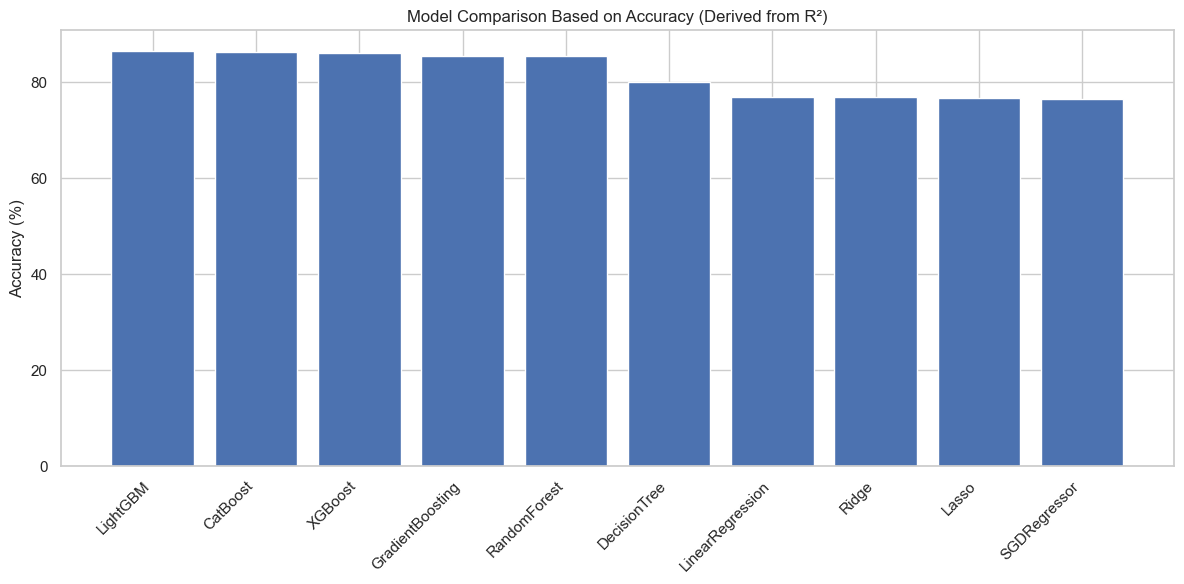

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.bar(results_df["model"], results_df["Accuracy (%)"])
plt.xticks(rotation=45, ha='right')
plt.ylabel("Accuracy (%)")
plt.title("Model Comparison Based on Accuracy (Derived from R²)")
plt.tight_layout()
plt.show()


To confirm no overfitting — run train vs test comparison

In [21]:
from sklearn.metrics import r2_score

for name, model in models.items():
    pipeline = joblib.load(f"C:/Users/91786/Desktop/Real_Estate_Price/models/{name}_pipeline.joblib")
    
    y_pred_train = pipeline.predict(X_train)
    y_pred_test = pipeline.predict(X_test)

    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)

    print(f"🔹 {name}")
    print(f"   Train R²: {r2_train:.4f}")
    print(f"   Test  R²: {r2_test:.4f}")
    print("-------------------------------------------")


🔹 LinearRegression
   Train R²: 0.7791
   Test  R²: 0.7693
-------------------------------------------
🔹 Ridge
   Train R²: 0.7786
   Test  R²: 0.7692
-------------------------------------------
🔹 Lasso
   Train R²: 0.7781
   Test  R²: 0.7677
-------------------------------------------
🔹 DecisionTree
   Train R²: 0.9574
   Test  R²: 0.8016
-------------------------------------------
🔹 RandomForest
   Train R²: 0.9663
   Test  R²: 0.8558
-------------------------------------------
🔹 GradientBoosting
   Train R²: 0.8772
   Test  R²: 0.8560
-------------------------------------------
🔹 XGBoost
   Train R²: 0.9298
   Test  R²: 0.8607
-------------------------------------------
🔹 LightGBM
   Train R²: 0.9133
   Test  R²: 0.8654
-------------------------------------------
🔹 CatBoost
   Train R²: 0.9011
   Test  R²: 0.8641
-------------------------------------------
🔹 SGDRegressor
   Train R²: 0.7680
   Test  R²: 0.7660
-------------------------------------------


Advanced Model Combination Techniques (Ensembles)

Prediction Code

In [26]:
### import joblib
import pandas as pd

# ------------------------------------------------------------
# Load trained Gradient Boosting model pipeline
# ------------------------------------------------------------
MODEL_PATH = r"C:\Users\91786\Desktop\Real_Estate_Price\models\GradientBoosting_pipeline.joblib"
model = joblib.load(MODEL_PATH)
print("Model loaded successfully!")

# ------------------------------------------------------------
# Prediction Function
# ------------------------------------------------------------
def predict_price():

    print("\nEnter property details for price prediction:\n")

    region = input("Region name: ")
    bhk = float(input("Number of BHK: "))
    total_sqft = float(input("Total area (sqft): "))
    property_type = input("Property Type (Apartment, Studio Apartment, Independent House, etc.): ")
    latitude = float(input("Latitude: "))
    longitude = float(input("Longitude: "))
    ndvi = float(input("NDVI value: "))
    ndbi = float(input("NDBI value: "))
    nightlight = float(input("Nightlight intensity: "))

    # Create df in same structure as training
    df = pd.DataFrame([{
        "city": "Mumbai",
        "location": region,
        "region": region,
        "bhk": bhk,
        "total_sqft": total_sqft,
        "property_type": property_type,
        "availability": "Ready to Go",
        "latitude": latitude,
        "longitude": longitude,
        "ndvi": ndvi,
        "ndbi": ndbi,
        "nightlight": nightlight
    }])

    # Predict using trained model pipeline
    predicted_price = model.predict(df)[0]

    # Price per sqft
    predicted_ppsqft = predicted_price / total_sqft

    print("\n================ PREDICTION RESULT ================")
    print(f"🏡 Predicted Price: ₹ {predicted_price:,.2f} Lakhs")
    print(f"📐 Price per Sqft: ₹ {predicted_ppsqft:,.2f} Lakhs")
    print("===================================================\n")


# ------------------------------------------------------------
# Start PredictionA
# ------------------------------------------------------------
predict_price()


Model loaded successfully!

Enter property details for price prediction:



Region name:  Andheri West
Number of BHK:  2
Total area (sqft):  1100
Property Type (Apartment, Studio Apartment, Independent House, etc.):  Independent House
Latitude:  19.117
Longitude:  72.833
NDVI value:  .84
NDBI value:  0.1
Nightlight intensity:  40.2



================ PREDICTION RESULT ================
🏡 Predicted Price: ₹ 187.64 Lakhs
📐 Price per Sqft: ₹ 0.17 Lakhs



In [ ]:
### import joblib
import pandas as pd

# ------------------------------------------------------------
# Load trained Gradient Boosting model pipeline
# ------------------------------------------------------------
MODEL_PATH = r"C:\Users\91786\Desktop\Real_Estate_Price\models\GradientBoosting_pipeline.joblib"
model = joblib.load(MODEL_PATH)
print("Model loaded successfully!")

# ------------------------------------------------------------
# Prediction Function
# ------------------------------------------------------------
def predict_price():

    print("\nEnter property details for price prediction:\n")

    region = input("Region name: ")
    bhk = float(input("Number of BHK: "))
    total_sqft = float(input("Total area (sqft): "))
    property_type = input("Property Type (Apartment, Studio Apartment, Independent House, etc.): ")
    latitude = float(input("Latitude: "))
    longitude = float(input("Longitude: "))
    ndvi = float(input("NDVI value: "))
    ndbi = float(input("NDBI value: "))
    nightlight = float(input("Nightlight intensity: "))

    # Create df in same structure as training
    df = pd.DataFrame([{
        "city": "Mumbai",
        "location": region,
        "region": region,
        "bhk": bhk,
        "total_sqft": total_sqft,
        "property_type": property_type,
        "availability": "Ready to Go",
        "latitude": latitude,
        "longitude": longitude,
        "ndvi": ndvi,
        "ndbi": ndbi,
        "nightlight": nightlight
    }])

    # Predict using trained model pipeline
    predicted_price = model.predict(df)[0]

    # Price per sqft
    predicted_ppsqft = predicted_price / total_sqft

    print("\n================ PREDICTION RESULT ================")
    print(f"🏡 Predicted Price: ₹ {predicted_price:,.2f} Lakhs")
    print(f"📐 Price per Sqft: ₹ {predicted_ppsqft:,.2f} Lakhs")
    print("===================================================\n")


# ------------------------------------------------------------
# Start PredictionA
# ------------------------------------------------------------
predict_price()


Model loaded successfully!

Enter property details for price prediction:

